In [12]:
!pip install xgboost

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [14]:
# Navigate into the data subfolder 
data = pd.read_csv('Datasets/StudentPerformanceFactors.csv')
print(data.head())
print(data.info())

   Hours_Studied  Attendance Parental_Involvement Access_to_Resources  \
0             23          84                  Low                High   
1             19          64                  Low              Medium   
2             24          98               Medium              Medium   
3             29          89                  Low              Medium   
4             19          92               Medium              Medium   

  Extracurricular_Activities  Sleep_Hours  Previous_Scores Motivation_Level  \
0                         No            7               73              Low   
1                         No            8               59              Low   
2                        Yes            7               91           Medium   
3                        Yes            8               98           Medium   
4                        Yes            6               65           Medium   

  Internet_Access  Tutoring_Sessions Family_Income Teacher_Quality  \
0             Ye

In [15]:
data = data.dropna()

In [16]:
# Separate features (X) and the target variable (y)
X = data.drop('Exam_Score', axis=1)
y = data['Exam_Score']

In [17]:
# Identify categorical columns
categorical_cols = X.select_dtypes(include=['object', 'category']).columns

C:\Users\Rabbi\AppData\Local\Temp\ipykernel_28112\799464885.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(include=['object', 'category']).columns


In [18]:
# Apply one-hot encoding to categorical columns
X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

In [19]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

print("Data preparation complete:")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

Data preparation complete:
X_train shape: (5102, 27)
X_test shape: (1276, 27)
y_train shape: (5102,)
y_test shape: (1276,)


In [20]:
# Initialize the Random Forest Regressor model
model = RandomForestRegressor(random_state=42)

# Train the model
model.fit(X_train, y_train)

print("Random Forest Regressor model trained successfully.")

Random Forest Regressor model trained successfully.


In [21]:
# Make predictions on the test data
y_pred_rf = model.predict(X_test)

# Calculate R-squared
r2 = r2_score(y_test, y_pred_rf)

# Calculate Mean Squared Error (MSE)
mse = mean_squared_error(y_test, y_pred_rf)

# Calculate Root Mean Squared Error (RMSE)
rmse = np.sqrt(mse)

# Print the evaluation metrics
print(f"R-squared: {r2:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")

R-squared: 0.6109
Mean Squared Error (MSE): 6.0461
Root Mean Squared Error (RMSE): 2.4589


In [22]:
# Initialize the XGBoost Regressor model
model_xgb = XGBRegressor(random_state=42)

# Train the model
model_xgb.fit(X_train, y_train)

print("XGBoost Regressor model trained successfully.")

XGBoost Regressor model trained successfully.


In [23]:
# Make predictions on the test data using the trained XGBoost model
y_pred_xgb = model_xgb.predict(X_test)

# Calculate R-squared
r2_xgb = r2_score(y_test, y_pred_xgb)

# Calculate Mean Squared Error (MSE)
mse_xgb = mean_squared_error(y_test, y_pred_xgb)

# Calculate Root Mean Squared Error (RMSE)
rmse_xgb = np.sqrt(mse_xgb)

# Print the evaluation metrics
print(f"XGBoost Regressor Performance:")
print(f"R-squared: {r2_xgb:.4f}")
print(f"Mean Squared Error (MSE): {mse_xgb:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse_xgb:.4f}")

XGBoost Regressor Performance:
R-squared: 0.6499
Mean Squared Error (MSE): 5.4397
Root Mean Squared Error (RMSE): 2.3323


In [24]:
# Create a DataFrame to store the metrics
metrics_data = {
    'Metric': ['R-squared', 'MSE', 'RMSE'],
    'Random Forest': [r2, mse, rmse],
    'XGBoost': [r2_xgb, mse_xgb, rmse_xgb]
}
metrics_df = pd.DataFrame(metrics_data)

print("Performance Metrics DataFrame:")
print(metrics_df)

Performance Metrics DataFrame:
      Metric  Random Forest   XGBoost
0  R-squared       0.610918  0.649937
1        MSE       6.046076  5.439747
2       RMSE       2.458877  2.332326


In [25]:
# Melt the DataFrame for easier plotting with seaborn
metrics_melted = metrics_df.melt(id_vars='Metric', var_name='Model', value_name='Value')

<Axes: xlabel='Metric', ylabel='Value'>

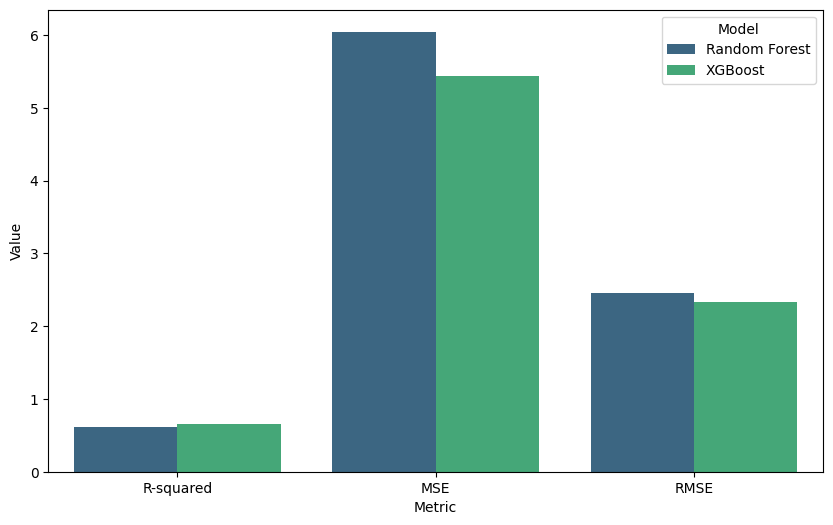

In [26]:
# Create the bar plot
plt.figure(figsize=(10, 6))
sns.barplot(x='Metric', y='Value', hue='Model', data=metrics_melted, palette='viridis')

C:\Users\Rabbi\AppData\Local\Temp\ipykernel_28112\2751544511.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='Model')


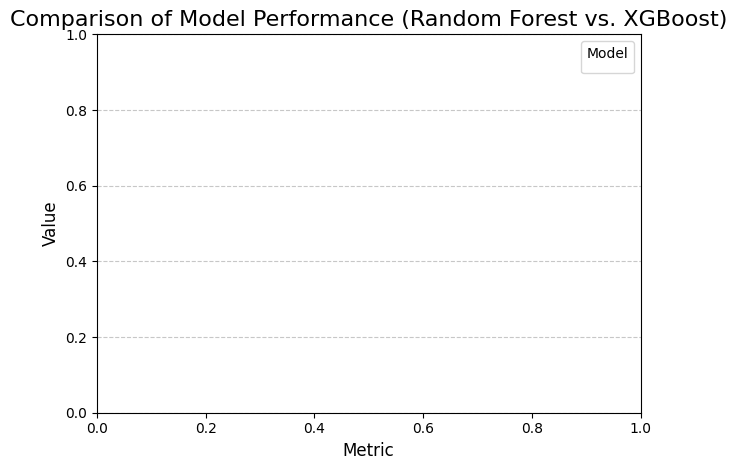

In [27]:
# Add title and labels
plt.title('Comparison of Model Performance (Random Forest vs. XGBoost)', fontsize=16)
plt.xlabel('Metric', fontsize=12)
plt.ylabel('Value', fontsize=12)
plt.legend(title='Model')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()